# Parallel Volume Rendering using Dask with multiple datasets

In [1]:
import sys
from pathlib import Path

repo = Path("/Users/mridulachandrika/Documents/Schoolwork/HPC-Intro")
source_dir = repo / "FinalProject" / "Source"
dataset_dir = repo / "FinalProject" / "dataset"

sys.path.insert(0, str(source_dir))
import volumerender_dask_multi as vr

print("Source:", source_dir)
print("Dataset:", dataset_dir)

Source: /Users/mridulachandrika/Documents/Schoolwork/HPC-Intro/FinalProject/Source
Dataset: /Users/mridulachandrika/Documents/Schoolwork/HPC-Intro/FinalProject/dataset


The code implements task-level parallelism using Dask delayed functions. Each viewing angle rendering task is independent, so it can be executed in parallel. 
render_angle_delayed(i, tiff_path, Nangles)
Renders one viewing angle of the volume. Dask schedules this function as a parallel task.

task = dask.delayed(render_angle_delayed)(i, str(tiff_path), Nangles)
result = dask.compute(task)[0]

Each task processes:

- a different camera angle

- the same 3D dataset

- This allows independent parallel execution.

['Sponge.tif', 'f_001.tif', 'vol_500.tif']

=== Sponge.tif ===


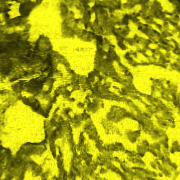

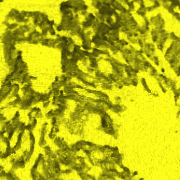

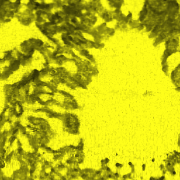

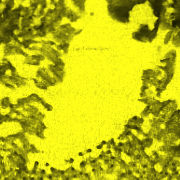


=== f_001.tif ===


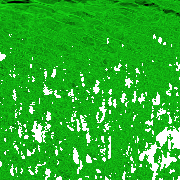

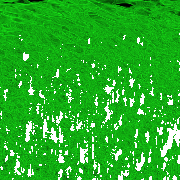

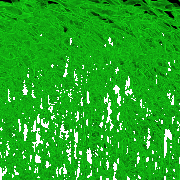

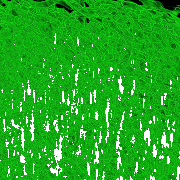


=== vol_500.tif ===


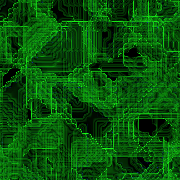

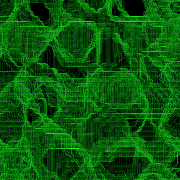

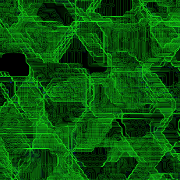

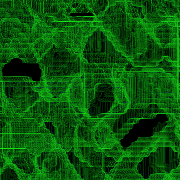

In [9]:

from pathlib import Path
from IPython.display import Image, display
import sys

repo = Path("/Users/mridulachandrika/Documents/Schoolwork/HPC-Intro")
source_dir = repo / "FinalProject" / "Source"
dataset_dir = repo / "FinalProject" / "dataset"

sys.path.insert(0, str(source_dir))
import volumerender_dask_multi as vr

tiff_files = sorted([p for p in dataset_dir.iterdir() if p.suffix.lower() in {".tif", ".tiff"}])
print([p.name for p in tiff_files])
for tiff_path in tiff_files:
    print(f"\n=== {tiff_path.name} ===")
    for i in range(4):  # start small to avoid memory pressure
        out_name = vr.render_angle_delayed(i, str(tiff_path), 4)
        display(Image(filename=out_name))